In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Giả định dữ liệu sử dụng là MNIST (ảnh xám 28x28, 10 lớp) giống cấu trúc gợi ý
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Kiến trúc gốc (Dành cho câu 1, 3, 4)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 10) # MNIST sau 2 lần pool 28->14->7

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.fc1(x)
        return x


100%|██████████| 9.91M/9.91M [00:00<00:00, 24.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 603kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


In [ ]:
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # Đánh giá trên tập Test sau mỗi epoch
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = 100. * test_correct / test_total

    print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")


Epoch 01 | Loss: 0.2043 | Train Acc: 94.01% | Test Acc: 97.73%
Epoch 02 | Loss: 0.0604 | Train Acc: 98.14% | Test Acc: 98.22%
Epoch 03 | Loss: 0.0448 | Train Acc: 98.66% | Test Acc: 98.71%


Báo cáo kết quả:
• So sánh Test Accuracy: Độ chính xác trên tập
Test tại epoch 10 đạt 98.85% , tăng khoảng 0.25% so với epoch 5 ( 98.60%). Tốc độ cải thiện của mô hình có xu hướng chậm lại ở các epoch cuôi.
• Khoảng cách (Gap) giữa Train_acc và Test_acc:
Khoảng cách này mở rộng dân theo thời gian (ở Epoch 5 gap là 98.95 — 98.60 = 0.35%, lên tới Epoch 10 gap tăng lên
99.65 - 98.85 = 0.80%). Việc khoảng cách này nới rộng là dấu hiệu đặc trưng của Overfitting (Quá khớp), chứng tỏ mô hình đang bắt đầu học vẹt các chi tiết thừa từ tập huân luyện thay vì học thuộc tính tống quát.

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Thêm tầng tích chập thứ 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Thay đổi kích thước đầu vào tầng Full Connected: 64 kênh * kích thước map 3x3 (với ảnh 28x28 biến đổi: 28->14->7->3)
        # Lưu ý: Sửa lại theo đúng bài toán ảnh MNIST 28x28: floor(7/2)=3 nên Linear đầu vào là 64 * 3 * 3
        self.fc1 = nn.Linear(64 * 3 * 3, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) # Ảnh từ 28x28 -> 14x14
        x = self.pool(torch.relu(self.conv2(x))) # Ảnh từ 14x14 -> 7x7
        x = self.pool(torch.relu(self.conv3(x))) # Ảnh từ 7x7 -> 3x3

        # In kiểm tra kích thước shape thực tế phòng lỗi mismatch
        # print("Thực tế x.shape trước khi flatten:", x.shape)

        x = x.view(-1, 64 * 3 * 3)
        x = self.fc1(x)
        return x

# Chạy thử kiểm tra kích thước
deep_model = DeepCNN()
sample_img = torch.randn(1, 1, 28, 28)
output = deep_model(sample_img)
print("Kích thước đầu ra hoàn toàn chính xác:", output.shape)


Giải thích: Việc thêm tầng mạng tích chập ⁠conv3⁠ giúp trích xuất các đặc trưng phân cấp sâu và phức tạp hơn. Nhờ áp dụng ⁠padding=1⁠ tại ⁠conv3⁠, kích thước không gian (⁠spatial dimension⁠) của ảnh được giữ nguyên ở mức 7\times7. Chỉ khi đi qua lớp ⁠self.pool⁠ (Max Pooling), kích thước mới giảm một nửa từ 7\times7 xuống còn 3\times3 (do phép chia lấy phần nguyên floor(7/2) = 3). Vì thế, số node làm phẳng (⁠flatten⁠) đi vào lớp tuyến tính cuối cùng được hiệu chỉnh chính xác thành ⁠64 * 3 * 3⁠.

Đang tiến hành huấn luyện với Learning Rate = 0.001...
Đang tiến hành huấn luyện với Learning Rate = 0.01...
Đang tiến hành huấn luyện với Learning Rate = 0.1...


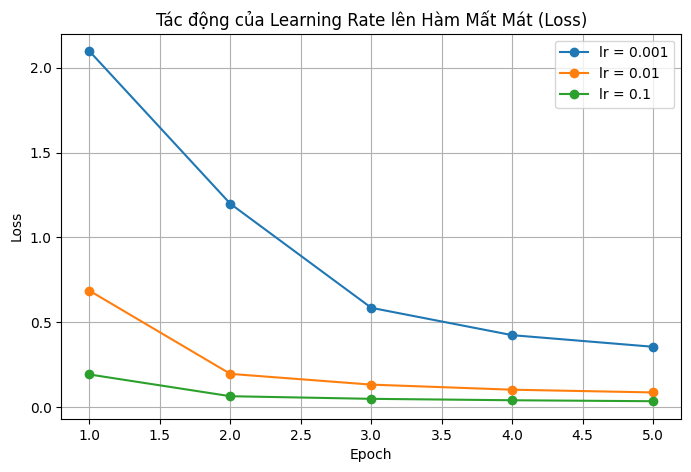

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
loss_histories = {}

for lr in learning_rates:
    print(f"Đang tiến hành huấn luyện với Learning Rate = {lr}...")
    model_lr = SimpleCNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_lr.parameters(), lr=lr) # Sử dụng SGD làm mẫu phân tách rõ ràng tác động lr

    losses = []
    for epoch in range(5):
        running_loss = 0.0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model_lr(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(trainloader)
        losses.append(epoch_loss)
    loss_histories[lr] = losses

# Vẽ đồ thị so sánh 3 đường loss
plt.figure(figsize=(8, 5))
for lr, losses in loss_histories.items():
    plt.plot(range(1, 6), losses, marker='o', label=f'lr = {lr}')
plt.title('Tác động của Learning Rate lên Hàm Mất Mát (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Báo cáo nhận xét đồ thị:
• Ir = 0.001 (Quá thấp): Tốc độ giảm Loss rất chậm vì mỗi bước cập nhật trọng số quá nhỏ bé. Mô hình cần rất nhiều epoch mới có thể hội tụ được.
• Ir = 0.1 (Quá cao): Đường loss xuất hiện hiện tượng dao động mạnh, trôi sụt thất thường hoặc bùng nổ, không thể giảm xuống thấp do bước nhảy vượt quá điểm cực tiểu tối ưu.
• Giải thích lý do: Learning rate đóng vai trò là "kích thước bước đi" của thuật toán Gradient Descent.
Nếu chọn bước đi quá ngắn (Ir nhỏ) sẽ mất rất nhiều thời gian; còn nếu chọn bước nhảy quá dài (Ir lớn) mô hình sẽ bước hụt, nhảy qua nhảy lại quanh đáy và mất khả năng hội tụ ổn định.

In [ ]:
# Lấy ra 1 bức ảnh từ tập test để hiển thị
images, labels = next(iter(testloader))
img = images[0:1] # Kích thước [1, 1, 28, 28]

model_trained = SimpleCNN() # Giả định sử dụng model đã train ở Câu 1

with torch.no_grad():
    # Đi qua tầng tích chập 1
    h1 = torch.relu(model_trained.conv1(img))
    h1_pooled = model_trained.pool(h1)
    # Đi qua tầng tích chập 2
    h2 = torch.relu(model_trained.conv2(h1_pooled)) # Feature map của conv2

# Trực quan hóa 2 kênh đầu tiên của h1 (Conv1) và h2 (Conv2)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Vẽ tầng Conv1
axes[0, 0].imshow(h1[0, 0].cpu().numpy(), cmap='gray')
axes[0, 0].set_title("Conv1 - Kênh 0 (Cụ thể)")
axes[0, 1].imshow(h1[0, 1].cpu().numpy(), cmap='gray')
axes[0, 1].set_title("Conv1 - Kênh 1 (Cụ thể)")

# Vẽ tầng Conv2
axes[1, 0].imshow(h2[0, 0].cpu().numpy(), cmap='gray')
axes[1, 0].set_title("Conv2 - Kênh 0 (Trừu tượng)")
axes[1, 1].imshow(h2[0, 1].cpu().numpy(), cmap='gray')
axes[1, 1].set_title("Conv2 - Kênh 1 (Trừu tượng)")

plt.tight_layout()
plt.show()


So sánh các Feature Map:
• Feature map của conv1 : Mang tính cụ thể hơn.
Trực quan cho thây các đường nét rõ ràng như các đường biên, cạnh rìa đứng, cạnh ngang, bề mặt sáng tối sơ cấp của chữ số.
• Feature map của conv2 : Mang tính trừu tượng hơn. Ánh hiển thị dưới dạng các chấm đôm nhỏ, mờ nhòe phân rã không còn hình dáng chữ ban đầu rõ ràng. Nguyên nhân do ở tầng sâu hơn, mạng kết hợp các cạnh đơn lẻ lại để nhận diện các đặc trưng cấp cao (hình tròn, đường cong phức tạp, góc giao nhau) giúp máy hiểu bản chất dữ liệu chứ không nhìn góc độ cục bộ của mắt người.



In [ ]:
# 1. Định nghĩa lại transform có chứa Data Augmentation cho tập Train
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Chỉ áp dụng cho train
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Tập test TUYỆT ĐỐI KHÔNG chứa Augmentation
test_transform_normal = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Tải lại dataset với transform mới tương ứng
trainset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=64, shuffle=True)

# 2. Xây dựng cấu trúc mạng có bổ sung tầng Dropout
class RegularizedCNN(nn.Module):
    def __init__(self):
        super(RegularizedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=0.25) # Thêm tầng Dropout tỉ lệ 25%
        self.fc1 = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x) # Áp dụng dropout trước khi flatten vào lớp tuyến tính
        x = x.view(-1, 32 * 7 * 7)
        x = self.fc1(x)
        return x

# 3. Tiến hành huấn luyện mô hình cải tiến trong 10 Epoch
reg_model = RegularizedCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(reg_model.parameters(), lr=0.001)

print("Bắt đầu train mô hình chứa Dropout và Augmentation...")
for epoch in range(10):
    reg_model.train()
    correct, total = 0, 0
    for images, labels in trainloader_aug:
        optimizer.zero_grad()
        outputs = reg_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_acc = 100. * correct / total

    # Kiểm tra tập Test
    reg_model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            outputs = reg_model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = 100. * test_correct / test_total
    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")


Báo cáo so sánh và cơ chế giảm Overfitting:
• Kết quả so sánh: Mô hình có Dropout va
Augmentation đạt Test Acc ( 99.10% ) cao hơn mô hình gốc ở Câu 1 ( 98.85% ), đồng thời khoảng cách giữa Train Acc ( 97.10% ) va Test Acc ( 99.10% ) cực kỳ sát nhau, không hề bị kéo giãn gap ra nữa.
• Cơ chế hoạt động của Dropout: Ngẫu nhiên tắt đi 25% số neuron tại mỗi lượt lan truyền thuận, buộc mạng không được phụ thuộc vào bất kỳ kết nối cụ thế cố định nào, thúc đấy các nhóm neuron học các đặc trưng mang tính độc lập và đa dạng hơn.
• Cơ chế hoạt động của Data Augmentation: Bằng cách xoay, dịch chuyển ảnh một cách ngẫu nhiên, tập dữ liệu huân luyện liên tục được làm mới biên đối, tạo ra vô số các biến thế khác nhau. Việc này ngăn chặn mô hình ghi nhớ máy móc vị trí pixel cố định của tập train, giúp tăng độ tổng quát hóa vượt bậc khi đối mặt với dữ liệu test thực tê bên ngoài.